In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Input


In [15]:
# Load the CSV file
df = pd.read_csv("Final_SCATS_with_LatLong.csv")


In [16]:
# Clean up and sort data
df.dropna(inplace=True)
df['Timestamp'] = pd.to_datetime(df['Timestamp'])
df = df.sort_values(by='Timestamp')


In [17]:
# Training on the busiest site
site_id = df['Site ID'].value_counts().idxmax()
train_data = df[df['Site ID'] == site_id]


In [18]:
train_data = train_data.set_index('Timestamp').resample('h').sum()
scaler = MinMaxScaler()
scaled = scaler.fit_transform(train_data[['Volume']])


In [19]:
# Createing sequence and prediction
def create_sequences(data, window=4):
    X, y = [], []
    for i in range(len(data) - window):
        X.append(data[i:i+window])
        y.append(data[i+window])
    return np.array(X), np.array(y)

X, y = create_sequences(scaled, window=4)
X = X.reshape((X.shape[0], X.shape[1], 1))


In [20]:
# BPR Function for converting volume to travel time
def volume_to_travel_time(volume, free_flow_time=60, capacity=1000, alpha=0.15, beta=4):
    """
    Converts volume into travel time using the BPR formula.
    Adds 30 seconds for signal/intersection delay.
    """
    return free_flow_time * (1 + alpha * (volume / capacity) ** beta) + 30

In [21]:
# LSTM model
model = Sequential()
model.add(Input(shape=(X.shape[1], 1)))
model.add(LSTM(64))
model.add(Dense(1))
model.compile(optimizer='adam', loss='mse')


In [22]:
# Train the model
model.fit(X, y, epochs=20, batch_size=16, verbose=1)


Epoch 1/20
162/162 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.0093
Epoch 2/20
162/162 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0054
Epoch 3/20
162/162 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0034
Epoch 4/20
162/162 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0032
Epoch 5/20
162/162 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0025
Epoch 6/20
162/162 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0017
Epoch 7/20
162/162 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0018
Epoch 8/20
162/162 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0015
Epoch 9/20
162/162 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0016
Epoch 10/20
162/162 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0014
Epoch 11/20
162/162 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0016
Epoch 12/20
162/162 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0014
Epoch 13/20
162/162 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0014
Epoch 14/20
162/162 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0014
Epoch 15/20
162/162 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - lo

81/81 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


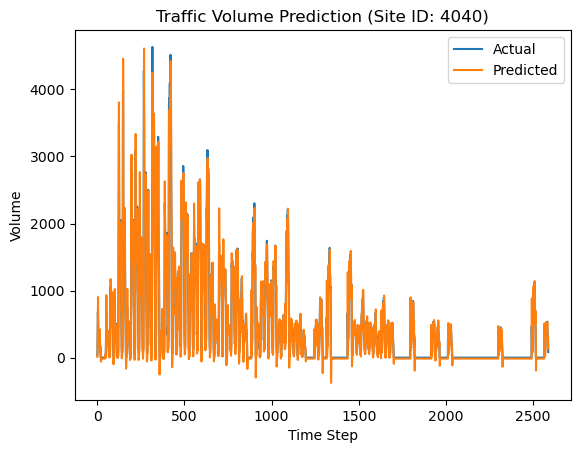

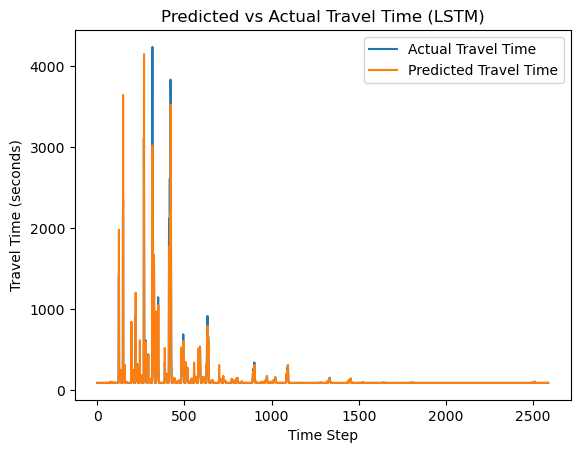

In [23]:
# Predict
predicted = model.predict(X)
predicted = scaler.inverse_transform(predicted)
actual = scaler.inverse_transform(y)

# Convert volumes to travel time using BPR function
predicted_travel_time = [volume_to_travel_time(v[0]) for v in predicted]
actual_travel_time = [volume_to_travel_time(v[0]) for v in actual]

# Ploting
plt.plot(actual, label="Actual")
plt.plot(predicted, label="Predicted")
plt.title("Traffic Volume Prediction (Site ID: {})".format(site_id))
plt.xlabel("Time Step")
plt.ylabel("Volume")
plt.legend()
plt.show()

plt.plot(actual_travel_time, label="Actual Travel Time")
plt.plot(predicted_travel_time, label="Predicted Travel Time")
plt.title("Predicted vs Actual Travel Time (LSTM)")
plt.xlabel("Time Step")
plt.ylabel("Travel Time (seconds)")
plt.legend()
plt.show()
